In [1]:
import pandas as pd
import numpy as np

In [72]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [73]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [74]:
df.dropna(inplace=True)

In [75]:
df.shape

(714, 3)

In [76]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [77]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [79]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [80]:
y_train.head()

328    1
73     0
253    0
719    0
666    0
Name: Survived, dtype: int64

In [81]:
clf = DecisionTreeClassifier()

In [82]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [83]:
accuracy_score(y_test,y_pred)

0.6503496503496503

In [84]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6345070422535211)

In [103]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile',quantile_method="averaged_inverted_cdf")
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile',quantile_method="averaged_inverted_cdf")

In [104]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [105]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [106]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15,
                  quantile_method='averaged_inverted_cdf'),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15,
                  quantile_method='averaged_inverted_cdf')}

In [107]:
trf.named_transformers_['first']

,n_bins,15
,encode,'ordinal'
,strategy,'quantile'
,quantile_method,'averaged_inverted_cdf'
,dtype,None
,subsample,200000
,random_state,None


In [108]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [109]:
output = pd.DataFrame({
    'age' :X_train['Age'],
    'age_trf' :X_train_trf[:,0],
    'fare' :X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [110]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                             bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                             bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [111]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
561,40.0,11.0,7.8958,3.0,"(38.0, 42.0]","(7.775, 7.896]"
380,42.0,12.0,227.5250,14.0,"(38.0, 42.0]","(108.9, 512.329]"
450,36.0,10.0,27.7500,10.0,"(35.0, 38.0]","(26.55, 31.275]"
628,26.0,6.0,7.8958,3.0,"(25.0, 28.0]","(7.775, 7.896]"
587,60.0,14.0,79.2000,13.0,"(54.0, 80.0]","(76.292, 108.9]"


## after column transform

In [112]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [113]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [114]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6316901408450704)

In [120]:
def descretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy,quantile_method="averaged_inverted_cdf")
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy,quantile_method="averaged_inverted_cdf")

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title('After')

    plt.show()

0.6864632237871675


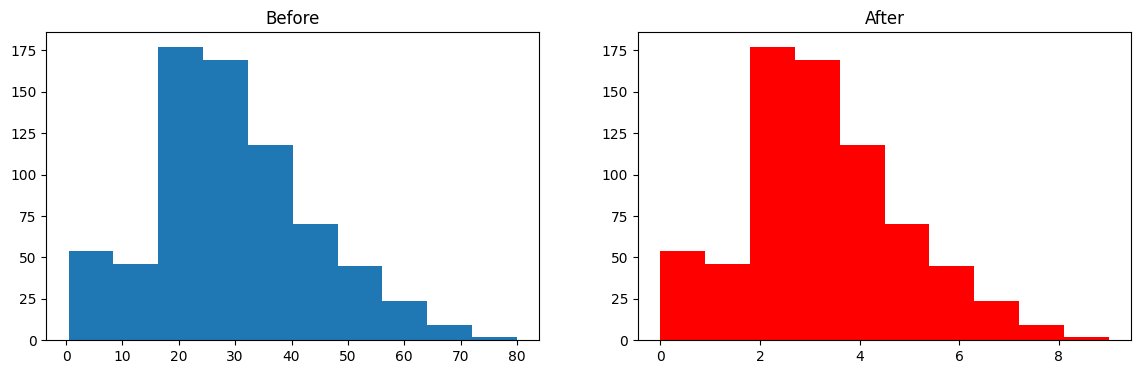

In [124]:
descretize(10,'uniform')